# 1. Objective of Evaluation and Explainability

The objective of this notebook is to perform the final evaluation of the selected fraud detection model and explain its predictions using SHAP.

After training and tuning the best XGBoost model in the previous notebook, this notebook focuses on two key tasks:

1. Evaluating the final model using appropriate metrics for imbalanced classification
2. Explaining the model's predictions to improve transparency and interpretability

Because fraud detection is a high-stakes application, model performance alone is not enough. It is also important to understand why the model predicts a transaction as fraudulent.

In this notebook, the following tasks are performed:

- Load the final trained XGBoost model
- Evaluate the model on the untouched test set
- Visualize performance using confusion matrix, ROC curve, and Precision-Recall curve
- Compare the final model with baseline models
- Introduce SHAP as an explainability method
- Analyze global feature importance
- Explain individual fraud predictions
- Interpret the meaning of the model’s behavior in a business context

This notebook provides the final evidence that the project model is both effective and explainable.

# 2. Import Libraries

In this section, the required libraries for evaluation, plotting, and SHAP explainability are imported.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import os

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

c:\Users\lenmo\Desktop\school-project\Credit-Card-Fraud-Detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3. Load Final Model and Test Data

The final tuned XGBoost model from Notebook 4 is loaded together with the untouched test dataset.

The test set remains unchanged from earlier preprocessing steps so that final evaluation reflects realistic performance on unseen data.

In [4]:
best_xgb_model = joblib.load("../models/final/best_xgboost_model.pkl")

X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Test feature shape:", X_test_scaled.shape)
print("Test label shape:", y_test.shape)

Test feature shape: (56962, 30)
Test label shape: (56962,)


In [5]:
print("Test class distribution:")
print(y_test.value_counts())

Test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


# 4. Final Model Evaluation

The final XGBoost model is evaluated using metrics that are suitable for imbalanced fraud detection.

The main evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

Among these, recall and PR-AUC are especially important because missing fraud cases is more costly than incorrectly flagging some legitimate transactions.

In [6]:
y_pred_final = best_xgb_model.predict(X_test_scaled)
y_prob_final = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

In [7]:
final_results = {
    "Model": "Final Tuned XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final, zero_division=0),
    "Recall": recall_score(y_test, y_pred_final, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_final, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_final),
    "PR-AUC": average_precision_score(y_test, y_prob_final)
}

pd.DataFrame([final_results])

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Final Tuned XGBoost,0.987132,0.109471,0.908163,0.19539,0.977504,0.730529


In [8]:
print("Final Classification Report:")
print(classification_report(y_test, y_pred_final, zero_division=0))

Final Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.11      0.91      0.20        98

    accuracy                           0.99     56962
   macro avg       0.55      0.95      0.59     56962
weighted avg       1.00      0.99      0.99     56962



# 5. Confusion Matrix

The confusion matrix shows how many transactions were classified correctly and incorrectly.

This is especially important in fraud detection because:

- False Positives = legitimate transactions incorrectly flagged as fraud
- False Negatives = fraud cases missed by the model

False negatives are often the most costly error in fraud detection systems.

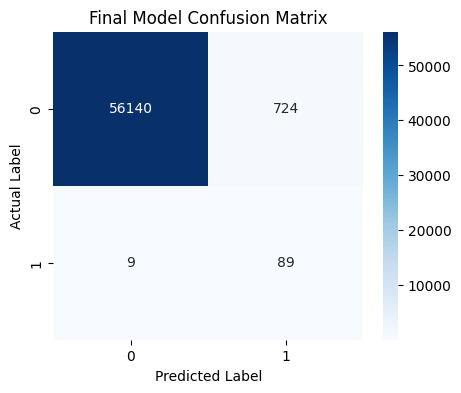

In [9]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# 6. ROC Curve

The ROC curve shows how well the model separates fraud and non-fraud classes across different threshold values.

Although ROC-AUC is useful, it can sometimes appear overly optimistic in highly imbalanced datasets, so it should be interpreted together with Precision-Recall results.

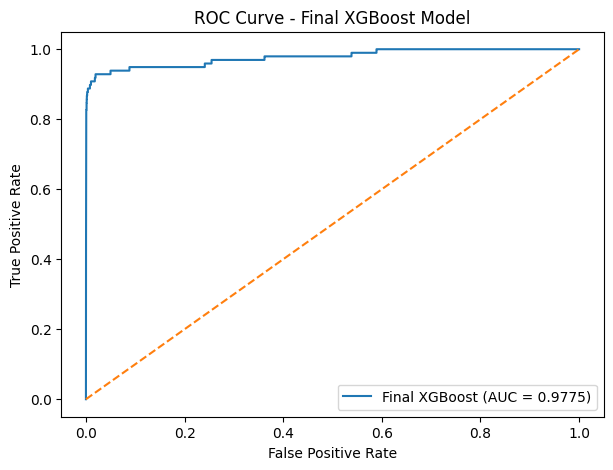

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
roc_auc = roc_auc_score(y_test, y_prob_final)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Final XGBoost (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost Model")
plt.legend()
plt.show()

# 7. Precision-Recall Curve

The Precision-Recall curve is especially important for fraud detection because the dataset is highly imbalanced.

This curve helps visualize the trade-off between precision and recall and provides a more realistic view of minority class performance than accuracy alone.

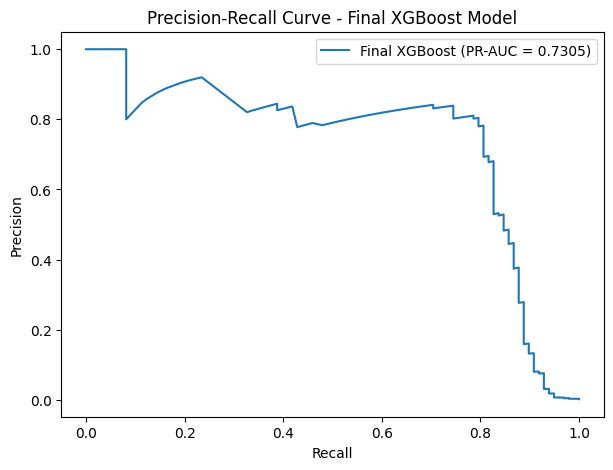

In [11]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob_final)
pr_auc = average_precision_score(y_test, y_prob_final)

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, label=f"Final XGBoost (PR-AUC = {pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final XGBoost Model")
plt.legend()
plt.show()

# 8. Model Comparison Summary

In this section, the final XGBoost model is compared with the baseline models from Notebook 3.

This helps demonstrate whether advanced modeling improved fraud detection performance.

In [12]:
baseline_results = pd.read_csv("../reports/tables/baseline_model_results.csv")
final_result_df = pd.DataFrame([final_results])

model_comparison_df = pd.concat([baseline_results, final_result_df], ignore_index=True)
model_comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.999596,0.941176,0.816327,0.874317,0.963027,0.873391
1,Logistic Regression,0.999140,0.826667,0.632653,0.716763,0.960549,0.741382
2,Final Tuned XGBoost,0.987132,0.109471,0.908163,0.195390,0.977504,0.730529


In [13]:
model_comparison_df = model_comparison_df.sort_values(by="Recall", ascending=False)
model_comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
2,Final Tuned XGBoost,0.987132,0.109471,0.908163,0.195390,0.977504,0.730529
0,Random Forest,0.999596,0.941176,0.816327,0.874317,0.963027,0.873391
1,Logistic Regression,0.999140,0.826667,0.632653,0.716763,0.960549,0.741382


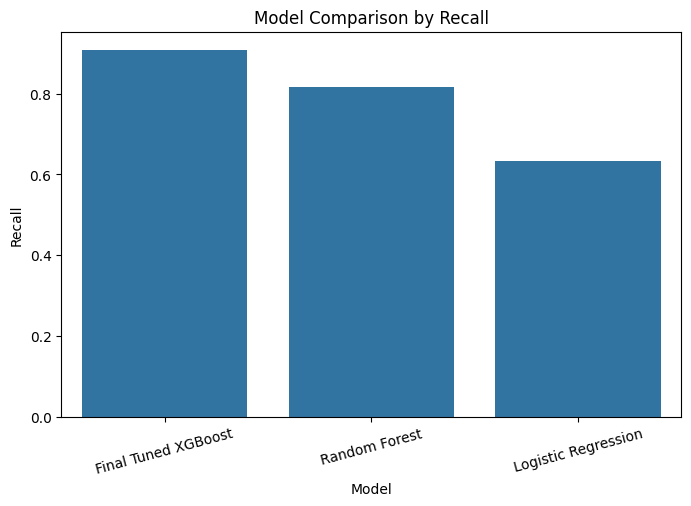

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(data=model_comparison_df, x="Model", y="Recall")
plt.title("Model Comparison by Recall")
plt.ylabel("Recall")
plt.xticks(rotation=15)
plt.show()

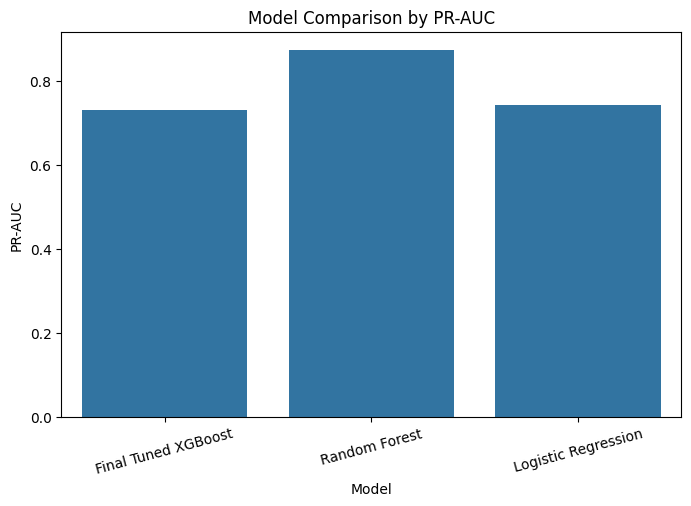

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=model_comparison_df, x="Model", y="PR-AUC")
plt.title("Model Comparison by PR-AUC")
plt.ylabel("PR-AUC")
plt.xticks(rotation=15)
plt.show()

# 9. Introduction to SHAP

SHAP (SHapley Additive exPlanations) is an explainable AI method used to understand how each feature contributes to a model's prediction.

SHAP is based on Shapley values from cooperative game theory and provides both:

- Global explanations: which features are important overall
- Local explanations: why a specific transaction was predicted as fraud or non-fraud

SHAP is particularly useful in fraud detection because financial systems require transparency, trust, and explainability in decision-making.

In [16]:
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# 10. Global Feature Importance with SHAP

Global feature importance shows which features have the strongest overall influence on the model's predictions across the full test dataset.

This helps identify the most important variables the model uses when distinguishing fraudulent from legitimate transactions.

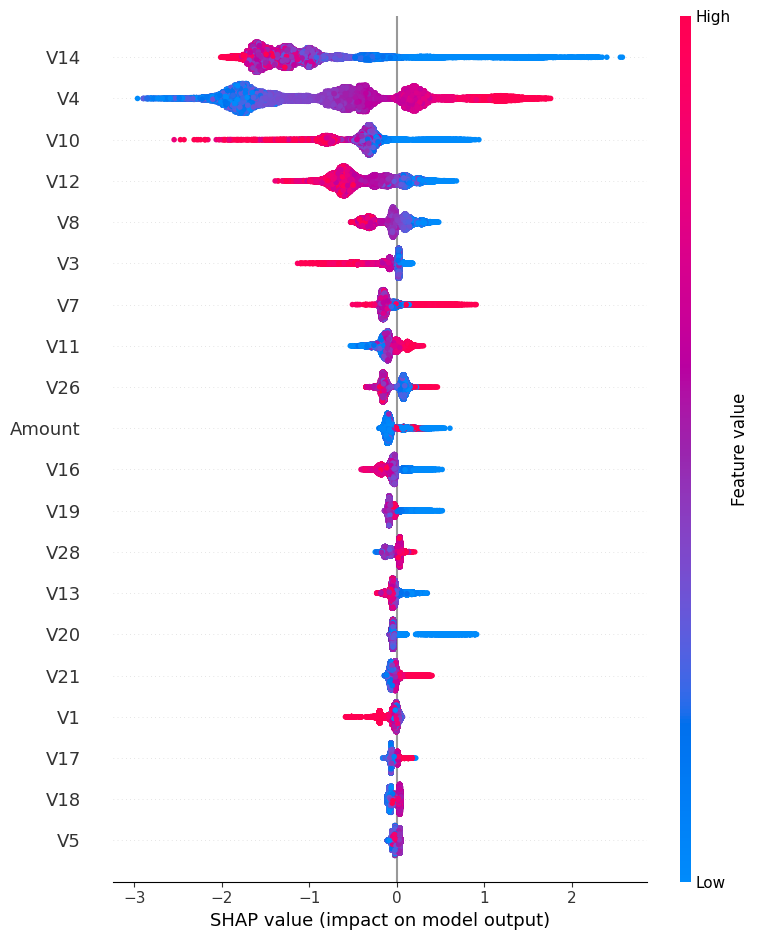

In [17]:
shap.summary_plot(shap_values, X_test_scaled)

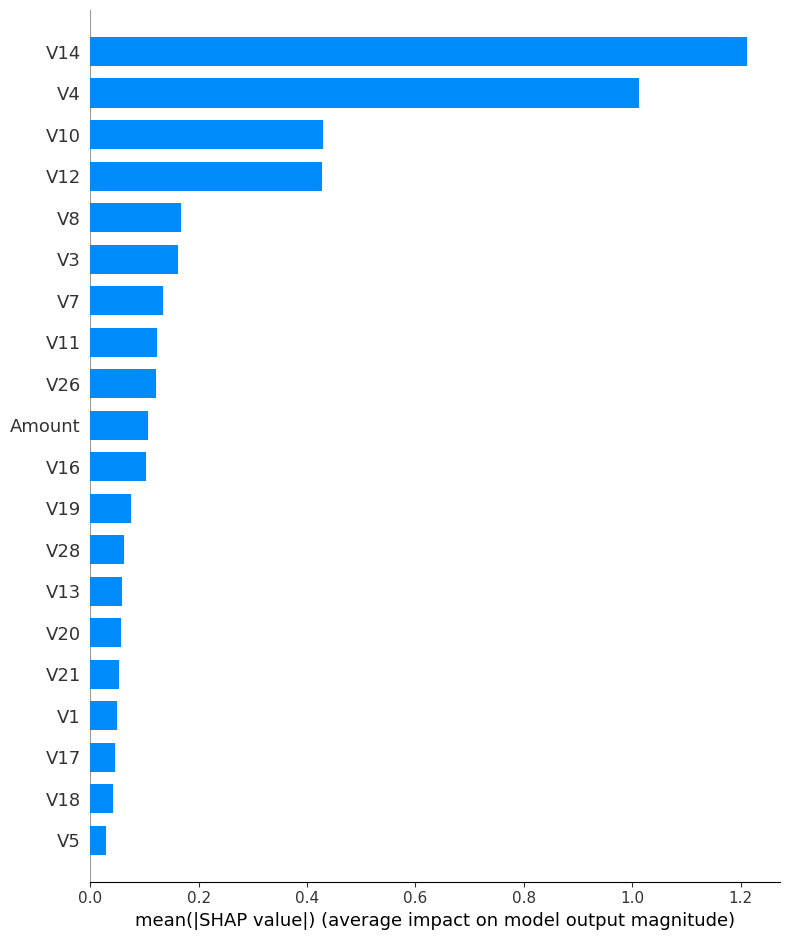

In [18]:
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar")

In [19]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

feature_importance_df = pd.DataFrame({
    "Feature": X_test_scaled.columns,
    "Mean |SHAP Value|": mean_abs_shap
}).sort_values(by="Mean |SHAP Value|", ascending=False)

feature_importance_df.head(10)

,Feature,Mean |SHAP Value|
14,V14,1.212122
4,V4,1.012806
10,V10,0.429435
12,V12,0.426987
8,V8,0.166566
3,V3,0.161384
7,V7,0.134284
11,V11,0.122751
26,V26,0.120617
29,Amount,0.107294


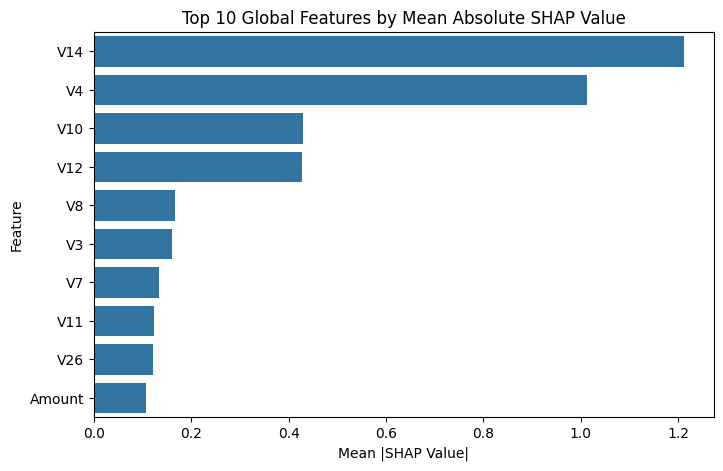

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=feature_importance_df.head(10),
    x="Mean |SHAP Value|",
    y="Feature"
)
plt.title("Top 10 Global Features by Mean Absolute SHAP Value")
plt.show()

# 11. Local Explanation for Individual Predictions

Local explanations help us understand why the model predicted a specific transaction as fraud or non-fraud.

This is important because fraud detection systems often require transaction-level justification for investigation and decision-making.

In [21]:
fraud_indices = np.where(y_pred_final == 1)[0]
fraud_indices[:10]

array([  4, 165, 279, 310, 426, 457, 518, 581, 586, 741])

In [22]:
sample_fraud_index = fraud_indices[0]
sample_fraud_index

np.int64(4)

In [23]:
print("Predicted label:", y_pred_final[sample_fraud_index])
print("Actual label:", y_test.iloc[sample_fraud_index])
print("Predicted fraud probability:", y_prob_final[sample_fraud_index])

Predicted label: 1
Actual label: 0
Predicted fraud probability: 0.7286771


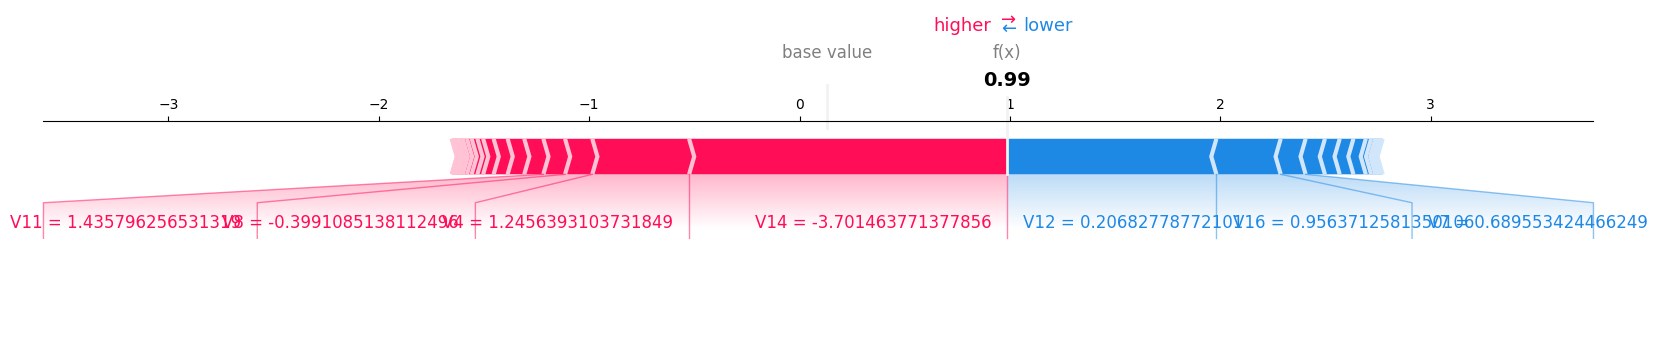

In [24]:
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_fraud_index],
    X_test_scaled.iloc[sample_fraud_index],
    matplotlib=True
)

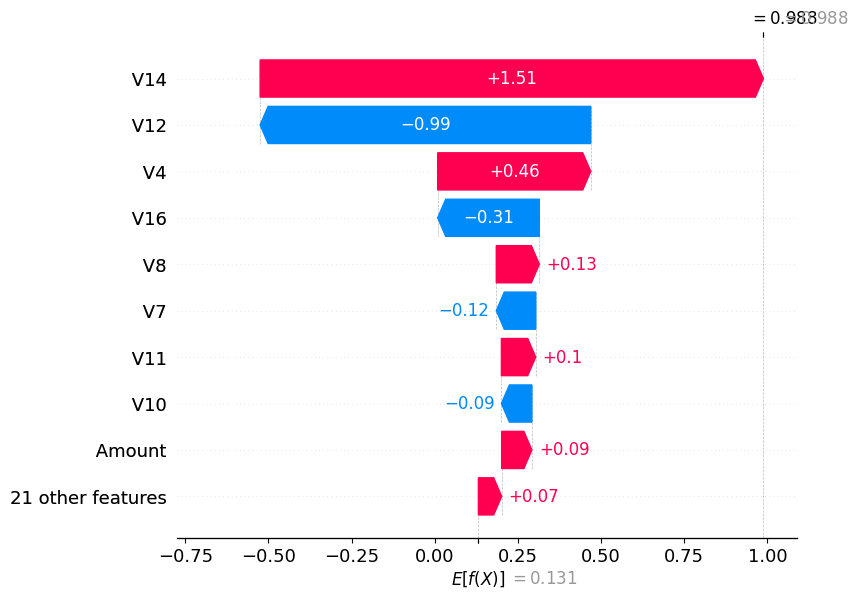

In [25]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[sample_fraud_index],
    X_test_scaled.iloc[sample_fraud_index]
)

In [26]:
normal_indices = np.where(y_pred_final == 0)[0]
sample_normal_index = normal_indices[0]

print("Predicted label:", y_pred_final[sample_normal_index])
print("Actual label:", y_test.iloc[sample_normal_index])
print("Predicted fraud probability:", y_prob_final[sample_normal_index])

Predicted label: 0
Actual label: 0
Predicted fraud probability: 0.021760337


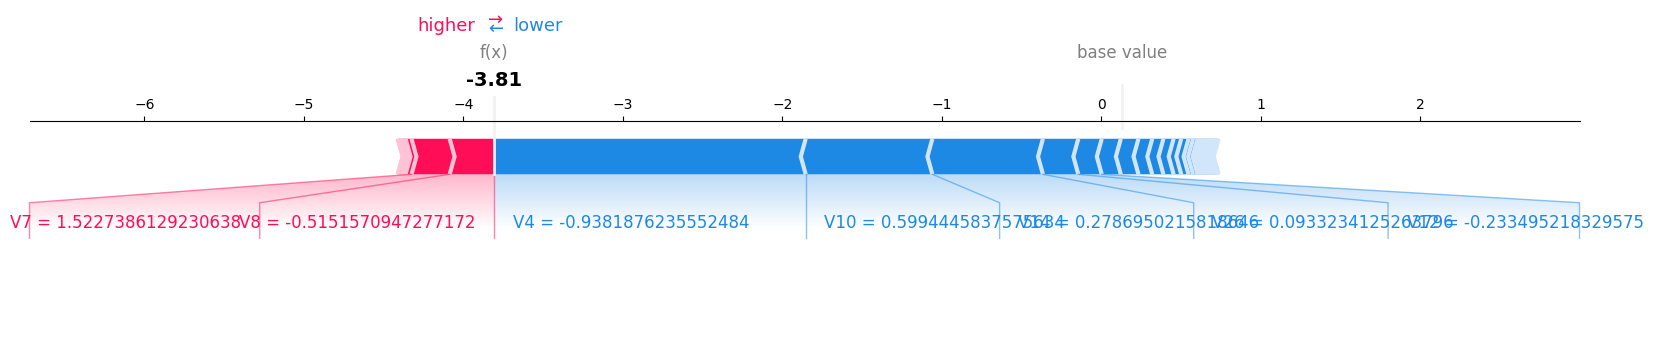

In [27]:
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_normal_index],
    X_test_scaled.iloc[sample_normal_index],
    matplotlib=True
)

# 12. Interpretation of Fraud Predictions

The SHAP results help us interpret how the model identifies suspicious behavior.

For fraud-predicted transactions, the model may rely on certain features with strong positive SHAP values that push the prediction toward the fraud class.

For legitimate transactions, other features may push the prediction toward the non-fraud class.

Because many dataset features are anonymized (`V1` to `V28`), the exact business meaning of each variable is unknown. However, SHAP still allows us to identify which features are influential and how strongly they affect the prediction.

This improves trust in the model even when the raw features are anonymized.

In [28]:
local_explanation_df = pd.DataFrame({
    "Feature": X_test_scaled.columns,
    "Feature Value": X_test_scaled.iloc[sample_fraud_index].values,
    "SHAP Value": shap_values[sample_fraud_index]
}).sort_values(by="SHAP Value", ascending=False)

local_explanation_df.head(10)

,Feature,Feature Value,SHAP Value
14,V14,-3.701464,1.512873
4,V4,1.245639,0.460133
8,V8,-0.399109,0.129451
11,V11,1.435796,0.103151
29,Amount,-0.345707,0.090799
17,V17,3.370570,0.079135
26,V26,-0.686087,0.066470
28,V28,0.319244,0.049729
3,V3,-0.886397,0.027451
18,V18,1.240823,0.027237


In [29]:
local_explanation_df.tail(10)

,Feature,Feature Value,SHAP Value
23,V23,-0.246537,-0.014588
20,V20,0.013080,-0.020024
6,V6,-1.586680,-0.025211
15,V15,1.011136,-0.059004
21,V21,-0.223665,-0.065280
13,V13,0.739392,-0.070232
10,V10,-1.453869,-0.091592
7,V7,0.689553,-0.118528
16,V16,0.956371,-0.305646
12,V12,0.206828,-0.993886


# 13. Business Meaning of Results

The final model results have important business implications for fraud detection systems.

## 1. Improved fraud detection
A higher recall means the model can detect more fraudulent transactions, reducing potential financial loss.

## 2. Trade-off between fraud detection and customer inconvenience
If the model flags too many legitimate transactions as fraud, it may create friction for customers. Therefore, precision and threshold tuning are also important.

## 3. Explainability increases trust
SHAP explanations make it possible to understand why a transaction was flagged, which is valuable for fraud analysts, compliance teams, and financial institutions.

## 4. Practical deployment potential
Because the final model produces both fraud probability and interpretable explanations, it is suitable for integration into a real-time fraud scoring system.

## 5. Support for decision-making
The model can assist human investigators by prioritizing suspicious transactions and showing the strongest contributing factors.

# 14. Final Insights

This notebook provided the final evaluation and explainability analysis for the fraud detection model.

The key insights are:

1. The tuned XGBoost model achieved stronger fraud detection performance than the baseline models.
2. Evaluation using recall and PR-AUC provided a more meaningful assessment than accuracy alone.
3. The confusion matrix and classification report showed how the model handled both fraud and legitimate transactions.
4. SHAP successfully explained both global feature importance and individual transaction predictions.
5. Even though many features are anonymized, SHAP still improved transparency and interpretability.
6. The final model is suitable for the next stage of the project, including deployment through FastAPI and Streamlit.

Overall, the final fraud detection system is not only effective, but also explainable and practical for real-world use.

In [30]:
os.makedirs("../reports/tables", exist_ok=True)
model_comparison_df.to_csv("../reports/tables/final_model_comparison.csv", index=False)
feature_importance_df.to_csv("../reports/tables/shap_global_feature_importance.csv", index=False)

print("Evaluation and SHAP tables saved successfully.")

Evaluation and SHAP tables saved successfully.


Notebook 5 performs the final evaluation of the selected XGBoost model and explains its predictions using SHAP.

It includes confusion matrix, ROC curve, Precision-Recall curve, comparison with baseline models, global feature importance, and local explanations for individual fraud predictions.

This notebook demonstrates that the final model is both accurate and interpretable.